<h3>Title and Objective</h3>

In [ ]:
# Phishing Website Detection - Machine Learning Model Building and Evaluation
# Objective: The objective of this phase is to train, compare, and evaluate multiple machine learning classification models on the cleaned phishing website dataset in order to detect whether a website is phishing or legitimate. This phase includes model training, performance comparison, cross-validation, hyperparameter tuning, ROC analysis, and selection of the best model for final use.

<h3>Import Libraries</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

import joblib

<h3>Load Cleaned Dataset</h3>

In [2]:
df = pd.read_csv("../data/cleaned_phishing_dataset.csv")
df.head()

,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,2,0,0,1,0,0,0,0,0,0,...,1,2,0,892,0,0.0,0,0,0,1
1,2,0,1,3,0,3,0,2,0,0,...,1,2,1,9540,1,0.0,0,0,0,1
2,2,0,0,1,0,0,0,0,0,0,...,1,2,3,589,1,0.0,0,0,0,0
3,2,0,2,5,0,0,0,0,0,0,...,1,2,0,292,1,0.0,0,0,0,1
4,2,0,0,0,0,0,0,0,0,0,...,1,2,1,3597,0,1.0,0,0,0,0


<h3>Separate Features and Target</h3>

In [3]:
target_col = "phishing"

X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (87209, 111)
y shape: (87209,)


<h3>Train-Test Split</h3>

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (69767, 111)
Test shape: (17442, 111)


<h3>Feature Scaling</h3>

In [5]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

<h3>Train Logistic Regression</h3>

In [6]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

<h3>Evaluate Logistic Regression</h3>

In [7]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.9293085655314758
Precision: 0.8901539448364336
Recall: 0.9101492047876701
F1 Score: 0.9000405350628293
ROC-AUC: 0.9777888877715293
              precision    recall  f1-score   support

           0       0.95      0.94      0.95     11343
           1       0.89      0.91      0.90      6099

    accuracy                           0.93     17442
   macro avg       0.92      0.92      0.92     17442
weighted avg       0.93      0.93      0.93     17442



<h3>Confusion Matrix for Logistic Regression</h3>

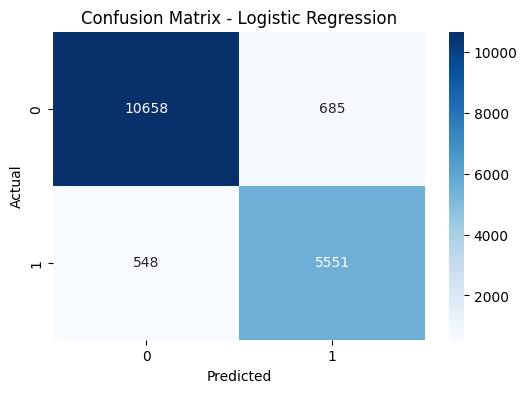

In [8]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<h3>Train Decision Tree</h3>

In [9]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)
y_prob_dt = dt.predict_proba(X_test_scaled)[:, 1]

<h3>Evaluate Decision Tree</h3>

In [10]:
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.9504070634101593
Precision: 0.9327050264550265
Recall: 0.9249057222495491
F1 Score: 0.9287890013995225
ROC-AUC: 0.9445056607123836
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     11343
           1       0.93      0.92      0.93      6099

    accuracy                           0.95     17442
   macro avg       0.95      0.94      0.95     17442
weighted avg       0.95      0.95      0.95     17442



<h3>Confusion Matrix for Decision Tree</h3>

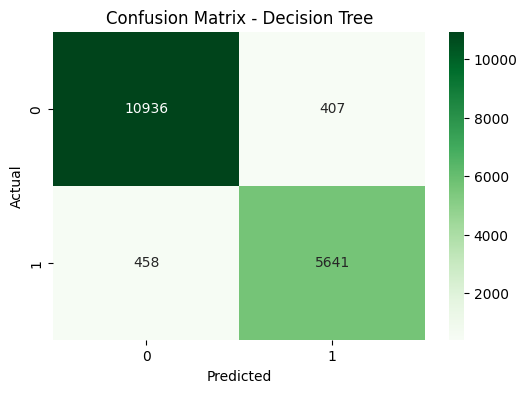

In [12]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<h3>Train Random Forest</h3>

In [13]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

<h3>Evaluate Random Forest</h3>

In [15]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9700722394220846
Precision: 0.9554140127388535
Recall: 0.9591736350221348
F1 Score: 0.9572901325478645
ROC-AUC: 0.9950494252341725
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11343
           1       0.96      0.96      0.96      6099

    accuracy                           0.97     17442
   macro avg       0.97      0.97      0.97     17442
weighted avg       0.97      0.97      0.97     17442



<h3>Confusion Matrix for Random Forest</h3>

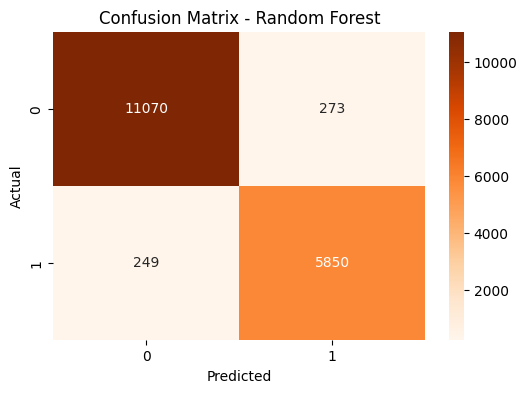

In [16]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<h3>Cross-Validation for Best Models</h3>

In [17]:
cv_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring="accuracy")
cv_dt = cross_val_score(dt, X_train_scaled, y_train, cv=5, scoring="accuracy")
cv_rf = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring="accuracy")

print("Logistic Regression CV Mean:", cv_lr.mean())
print("Decision Tree CV Mean:", cv_dt.mean())
print("Random Forest CV Mean:", cv_rf.mean())

Logistic Regression CV Mean: 0.9286626017291141
Decision Tree CV Mean: 0.9508506962618757
Random Forest CV Mean: 0.9687101462196009


<h3>Hyperparameter Tuning</h3>
<h5>Random Forest Tuning</h5>

In [19]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)

print("Best RF Params:", grid_rf.best_params_)
print("Best RF Score:", grid_rf.best_score_)

Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best RF Score: 0.9688391527892002


<h3>Plot ROC Curves</h3>

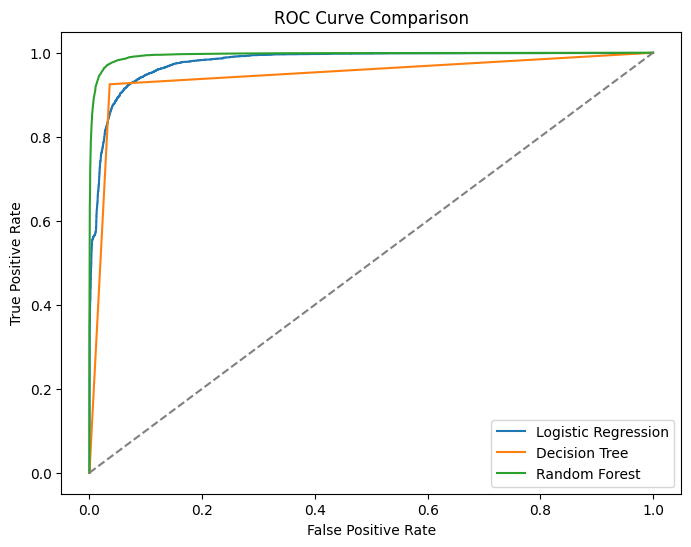

In [20]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

<h3>Compare All Models</h3>

In [21]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

display(results.sort_values(by="F1 Score", ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.970072,0.955414,0.959174,0.957290,0.995049
1,Decision Tree,0.950407,0.932705,0.924906,0.928789,0.944506
0,Logistic Regression,0.929309,0.890154,0.910149,0.900041,0.977789


<h3>Feature Importance from Best Model</h3>

In [22]:
feature_importance = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance.head(10))

,Feature,Importance
57,directory_length,0.126339
100,time_domain_activation,0.063368
55,qty_dollar_directory,0.050380
58,qty_dot_file,0.043795
43,qty_slash_directory,0.039190
18,length_url,0.036517
105,ttl_hostname,0.026587
56,qty_percent_directory,0.025512
99,asn_ip,0.024092
97,time_response,0.023937


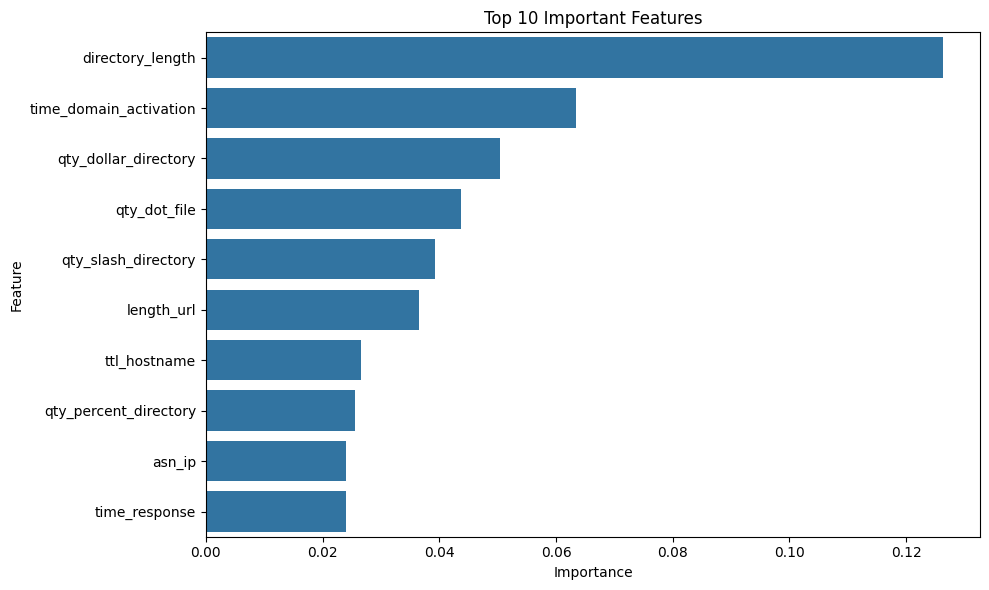

In [23]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

<h3>Save Final Model and Scalar</h3>

In [24]:
joblib.dump(rf, "../models/phishing_rf_model.pkl")
joblib.dump(scaler, "../models/phishing_scaler.pkl")

['../models/phishing_scaler.pkl']


## Model Building Summary

- Logistic Regression, Decision Tree, and Random Forest were trained.
- Their performance was compared using accuracy, precision, recall, F1-score, and ROC-AUC.
- Cross-validation was used to check consistency.
- Hyperparameter tuning was applied to improve Random Forest.
- ROC curves and confusion matrices were plotted for better evaluation.
- The best model was selected and saved for future use.